# Money Talks
Money Talks is the name of my final project. Through my analysis, I'll uncover the factors contributing to DC public employee salaries. The dataset consists of INSERT and was accessed on Open Data DC, [DC Public Employee Salary](https://opendata.dc.gov/datasets/DCGIS::dc-public-employee-salary/explore). This data is analytically compelling because it has significant real-world relevance that I'm curious about. Furthermore, it has a variety of data types and opportunities to challenge my Python skills.

## Obective and Research Questions
My objectve is to see which factors influence employee compensation.

My research questions are as follows:
* How does gender impact employee salary?
* How do grade and government appointment type influence salary?
* Which factor has the largest influence?

## Data Understanding and Cleaning 

First I'm going to import the necessary libraries that I'll need to complete both my cleaning and later analysis:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Then I'll load the dataset:

In [4]:
df=pd.read_csv('fp_dataset.csv')
df

,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp,40607
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp,40608
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg,40609
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg,40610


The first step in beginning to understand my dataset is displaying a couple of the rows, so I'll be using .head() to show the first 5 rows of the dataset:

In [5]:
df.head()

,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5


Next, I need to determine the shape, columns, and data types within the dataset:

In [6]:
df.shape

(40611, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40611 entries, 0 to 40610
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FIRST_NAME        40611 non-null  object 
 1   LAST_NAME         40611 non-null  object 
 2   JOBTITLE          40611 non-null  object 
 3   DESCRSHORT        40611 non-null  object 
 4   GRADE             40571 non-null  object 
 5   COMPRATE          40611 non-null  float64
 6   HIREDATE_STRING   40611 non-null  object 
 7   GVT_TYPE_OF_APPT  40611 non-null  object 
 8   OBJECTID          40611 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 2.8+ MB


Next I'll compute the summary statistics for numerical and categorical columns:

In [8]:
df.describe()

,COMPRATE,OBJECTID
count,40611.000000,40611.000000
mean,89087.755572,20306.000000
std,47453.788915,11723.530228
min,0.030000,1.000000
25%,66130.000000,10153.500000
50%,93234.000000,20306.000000
75%,119643.130000,30458.500000
max,390232.000000,40611.000000


In [9]:
df.describe(include='object')

,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,HIREDATE_STRING,GVT_TYPE_OF_APPT
count,40611,40611,40611,40611,40571,40611,40611
unique,12930,15110,3698,88,68,4914,18
top,Michael,Williams,OFFICER,DCPS,15,2025/08/11,CS - Reg
freq,466,588,2027,11764,7376,402,19794


Now that I've completed the necessary steps to understand the dataset I'm working with, I can begin cleaning! First, Ill check for any missing values.

In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

GRADE    40
dtype: int64

I have 40 missing values in the GRADE column. In order for me to decide how I want to handle these values, I need to see the percentage of missing values within the dataset

In [11]:
df.isnull().sum()[df.isnull().sum() > 0]/len(df)*100

GRADE    0.098495
dtype: float64

The missing values within the GRADE column represent less than 0.1% of the data within the dataset, so I'm going to drop the rows containing these missing values. This should not have an adverse impact on my analysis because my dataset is so large.

In [12]:
df.dropna(subset=['GRADE'], inplace=True)

Next, I'll identify any duplicate values/rows within the dataset

In [13]:
duplicates=df.duplicated().sum()
print(f'Number of duplicates:{duplicates}')

Number of duplicates:0


I'm going to make the column names lowercase for easier typing. Then, I'm going to standardize the data within the jobtitle column to make it more uniform and visually appealing

In [14]:
df.columns=df.columns.str.lower()
df

,first_name,last_name,jobtitle,descrshort,grade,comprate,hiredate_string,gvt_type_of_appt,objectid
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,ADJUNCT INSTRUCTOR - WDLL,UDC,01,0.03,2023/01/03,Ed - Temp,40607
40607,Pablo,Larreategui Plaza,Adjunct Professor-SEIU,UDC,01,210.00,2025/05/16,Ed - Temp,40608
40608,Myron,Douglas,ASST PROFESSOR,UDC,04,83843.46,2008/06/01,Ed - Reg,40609
40609,Yoko,Ferguson,ASSOCIATE PROFESSOR,UDC,03,91965.50,2022/08/16,Ed - Reg,40610


In [15]:
df['jobtitle']=df['jobtitle'].str.title()
df

,first_name,last_name,jobtitle,descrshort,grade,comprate,hiredate_string,gvt_type_of_appt,objectid
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,Psychiatric Nurse,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,Supervisory Psychiatric Nurse,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,Adjunct Instructor - Wdll,UDC,01,0.03,2023/01/03,Ed - Temp,40607
40607,Pablo,Larreategui Plaza,Adjunct Professor-Seiu,UDC,01,210.00,2025/05/16,Ed - Temp,40608
40608,Myron,Douglas,Asst Professor,UDC,04,83843.46,2008/06/01,Ed - Reg,40609
40609,Yoko,Ferguson,Associate Professor,UDC,03,91965.50,2022/08/16,Ed - Reg,40610


Next, I'll convert the dates in hiredate_string to datetime and rename the column so there's no confusion

In [16]:
df['hiredate_string']=pd.to_datetime(df['hiredate_string'])
df.rename(columns={'hiredate_string':'hiredate'}, inplace=True)
df

,first_name,last_name,jobtitle,descrshort,grade,comprate,hiredate,gvt_type_of_appt,objectid
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004-10-18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,Psychiatric Nurse,DBH,09,115907.00,2020-08-17,CS - Reg,2
2,Hadizat,Elayo-Ross,Supervisory Psychiatric Nurse,DBH,13,122500.00,2023-08-14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985-08-27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016-11-14,CS - Reg,5
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,Adjunct Instructor - Wdll,UDC,01,0.03,2023-01-03,Ed - Temp,40607
40607,Pablo,Larreategui Plaza,Adjunct Professor-Seiu,UDC,01,210.00,2025-05-16,Ed - Temp,40608
40608,Myron,Douglas,Asst Professor,UDC,04,83843.46,2008-06-01,Ed - Reg,40609
40609,Yoko,Ferguson,Associate Professor,UDC,03,91965.50,2022-08-16,Ed - Reg,40610


As part of the final parts of my cleaning, I'm going to drop the objectid column. It's redundant because it only serves as a counter of each entry, which Jupyter/python already provides me with. Additionally, because my analysis is focused on gender, I'm going to add a gender column. I will be randomly assigning gender to each entry. Because the gender variable is simulated randomly, I know that the trends reflected in my later visualizations will not be representative of the real-world. However, I still want to include this because I'm curious to see the results and the code structure would be appropriate to analyze the trends if I had access to the actual genders

In [17]:
df_new=df.drop(columns=['objectid'])
np.random.seed(42)
df_new['gender']=np.random.choice(['Female', 'Male'], size=len(df), p=[0.52, 0.48])
df_new

,first_name,last_name,jobtitle,descrshort,grade,comprate,hiredate,gvt_type_of_appt,gender
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004-10-18,CS - Reg,Female
1,Korlu,Wolobah-Kuyon,Psychiatric Nurse,DBH,09,115907.00,2020-08-17,CS - Reg,Male
2,Hadizat,Elayo-Ross,Supervisory Psychiatric Nurse,DBH,13,122500.00,2023-08-14,MSS - Reg,Male
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985-08-27,CS - Reg,Male
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016-11-14,CS - Reg,Female
...,...,...,...,...,...,...,...,...,...
40606,Zaid,Coleman,Adjunct Instructor - Wdll,UDC,01,0.03,2023-01-03,Ed - Temp,Female
40607,Pablo,Larreategui Plaza,Adjunct Professor-Seiu,UDC,01,210.00,2025-05-16,Ed - Temp,Female
40608,Myron,Douglas,Asst Professor,UDC,04,83843.46,2008-06-01,Ed - Reg,Male
40609,Yoko,Ferguson,Associate Professor,UDC,03,91965.50,2022-08-16,Ed - Reg,Female


## Exploratory Data Analysis

I'm curious to see the frequency/value counts of categorical columns like grade and jobtitle:

In [18]:
df_new['grade'].value_counts()

grade
15     7376
01     4190
12     3911
11     3159
13     2989
       ... 
2B1       2
E3        2
2D1       1
2C1       1
6A        1
Name: count, Length: 68, dtype: int64

In [19]:
df_new['jobtitle'].value_counts()

jobtitle
Officer                           2027
Teacher, General Elementary       1369
Teacher, Special Ed.              1010
Firefighter Emt                    971
Teacher, General Secondary         828
                                  ... 
Senior Contract Specialist           1
Dep Chf St/Dir Cor Rel               1
Marketing Communications Manag       1
Associate Director, Law Librar       1
Assoc. Prof/Div. Dir. Business       1
Name: count, Length: 3543, dtype: int64

Because I convereted hiredate to datetime, I can look at hiring trends by year!

In [20]:
df_new['hire_year']=df['hiredate'].dt.year
print(df_new['hire_year'].value_counts().sort_index())

hire_year
1966       4
1968       2
1969       9
1970       4
1971       7
1972       6
1973      13
1974       8
1975       8
1976      10
1977      14
1978      16
1979      13
1980      20
1981      18
1982      29
1983      37
1984      58
1985      85
1986     118
1987     178
1988     150
1989     147
1990     201
1991     124
1992     177
1993     156
1994     157
1995     114
1996     142
1997     262
1998     333
1999     489
2000     703
2001     631
2002     584
2003     626
2004     883
2005     967
2006     973
2007    1176
2008    1157
2009    1066
2010     794
2011     759
2012     959
2013    1319
2014    1415
2015    1608
2016    1608
2017    1725
2018    1702
2019    1884
2020    1364
2021    1672
2022    2600
2023    2971
2024    3099
2025    3217
Name: count, dtype: int64


I'll also compare the average compensation across different grades:

In [21]:
grade_comp=df_new.groupby('grade')['comprate'].mean().sort_values(ascending=False)
print(grade_comp)

grade
5C     354985.461538
6C     325128.550000
EX     309375.575000
PS3    287832.786000
3B     281815.000000
           ...      
30      34206.240000
03      25999.644209
17       5154.121655
35         60.000000
40         60.000000
Name: comprate, Length: 68, dtype: float64


I'm also gonna look at outliers in compensation, just to get a better idea of what I'm working with

In [22]:
Q1=df_new['comprate'].quantile(0.25)
Q3=df_new['comprate'].quantile(0.75)
IQR=Q3-Q1
outliers=df_new[(df_new['comprate'] < (Q1 - 1.5 * IQR)) | (df['comprate'] > (Q3 + 1.5 *IQR))]
print(f'Number of compensation outliers:{len(outliers)}')

Number of compensation outliers:430


## Data Visualization and Interpretation

***Statement of Intent:*** The bar chart aims to establish a baseline for my analysis. It visualizes the the average annual compensation for employees grouped solely by gender to determine if a pay gap exists.

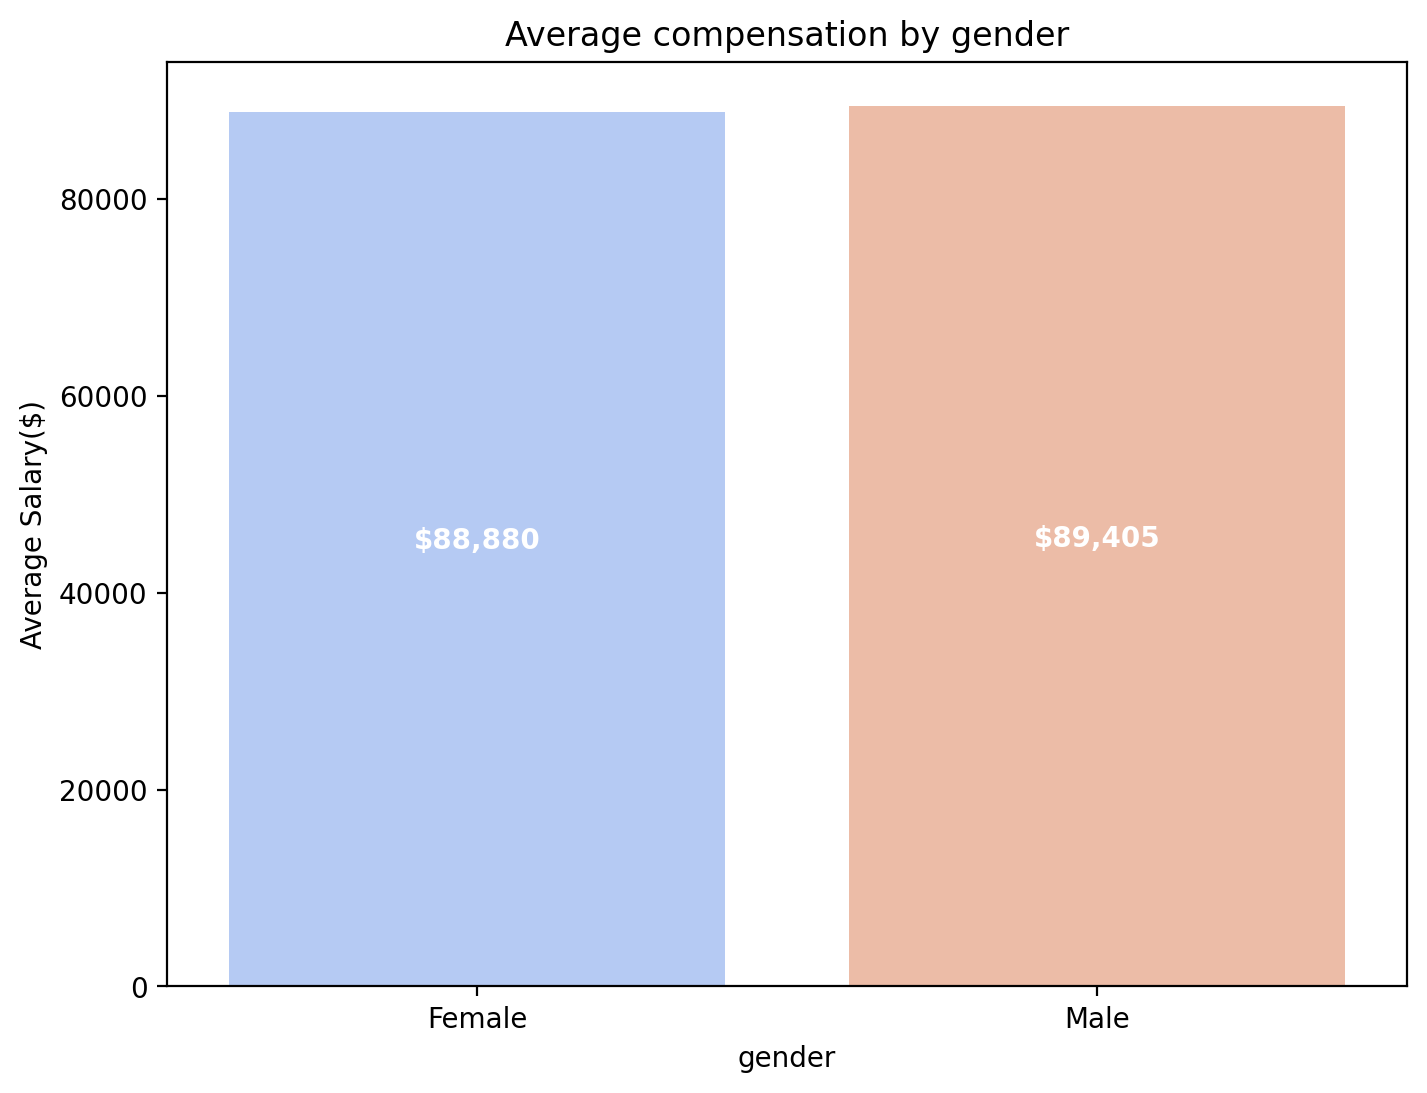

In [23]:
plt.figure(figsize=(8,6))
sns.barplot(data=df_new, x='gender', y='comprate', hue='gender', palette='coolwarm', errorbar=None, legend=False)
plt.title('Average compensation by gender')
plt.ylabel('Average Salary($)')
plt.xticks(rotation=0)
avg_f=df[df_new['gender'] == 'Female']['comprate'].mean()
avg_m=df[df_new['gender'] == 'Male']['comprate'].mean()
plt.text(0, avg_f/2, f'${avg_f:,.0f}', ha='center', color='white', fontweight='bold')
plt.text(1, avg_m/2, f'${avg_m:,.0f}', ha='center', color='white', fontweight='bold')
plt.savefig('visualizations/average_comp_by_gender.png')
plt.show()

***Interpretation:*** The visualization illustrates that the average yearly compensation for female employees ($88,880) is slightly lower than that for males ($89,405). So a gap exists, but it's relatively narrow, suggesting that gender may not be the primary factor driving the variance in this dataset.

***Statement of Intent:*** This box plot investigates the relationship between employee pay grades and compensation rates, broken down by gender to see if pay equity is maintained within the different grade levels.

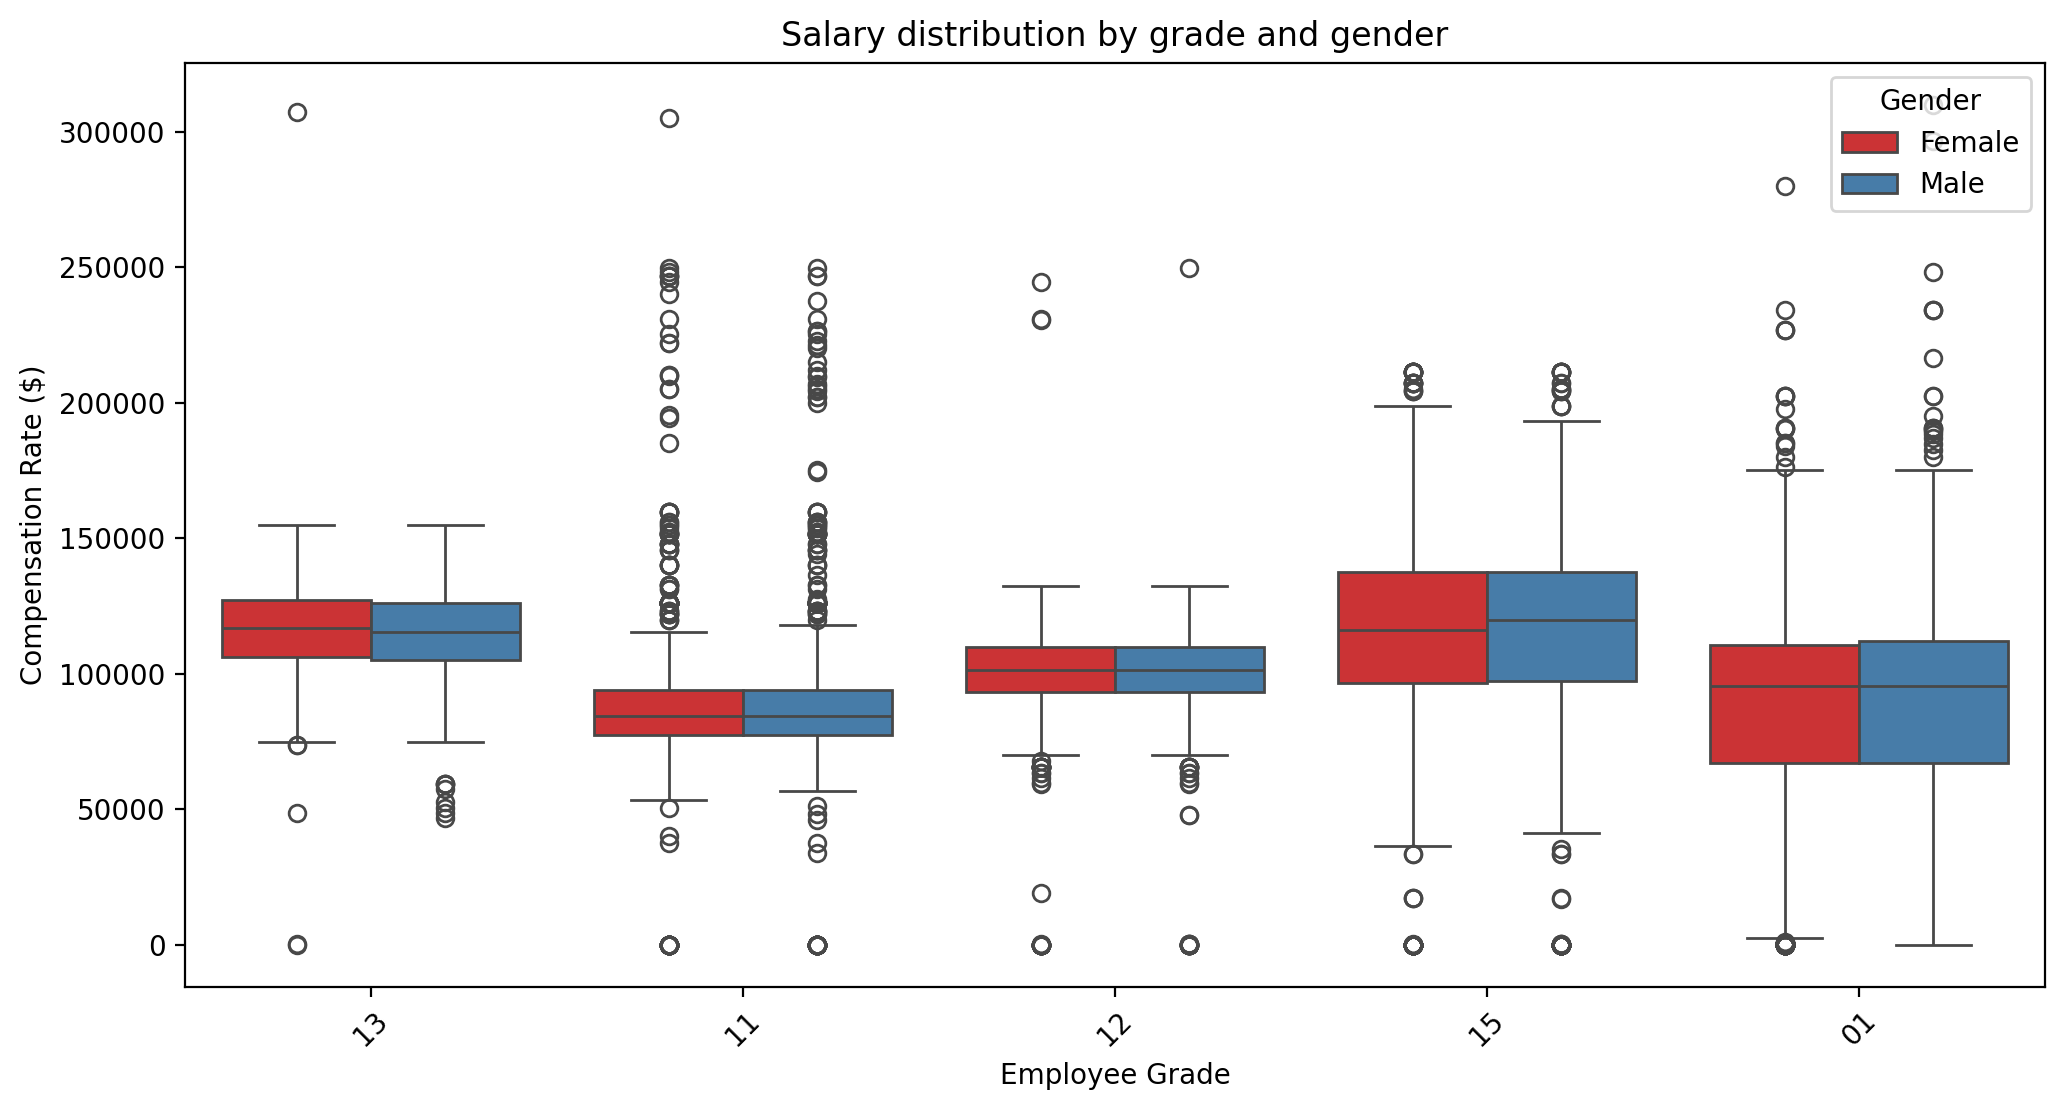

In [24]:
top_grades=df_new['grade'].value_counts().nlargest(5).index
subset=df_new[df_new['grade'].isin(top_grades)]
plt.figure(figsize=(12,6))
sns.boxplot(data=subset, x='grade', y='comprate', hue='gender', palette='Set1', legend=True)
plt.title('Salary distribution by grade and gender')
plt.xlabel('Employee Grade')
plt.ylabel('Compensation Rate ($)')
plt.xticks(rotation=45)
plt.legend(title='Gender', loc='upper right')
plt.savefig('visualizations/salary_dist_by_grade_and_gender.png')
plt.show()

***Interpretation:*** The plot shows a positive correlation between grades and compensation. With some variation, the median salaries across the grade levels are pretty similar for males and females. However, there are numerous outliers, suggesting that some individuals earn significantly more than others in their grade regardless of gender.  

***Statement of Intent:*** The grouped bar chart analyzes how different government appointment types impact compensation. It will also help me determine if gender disparities are more pronounced in certain appointment categories

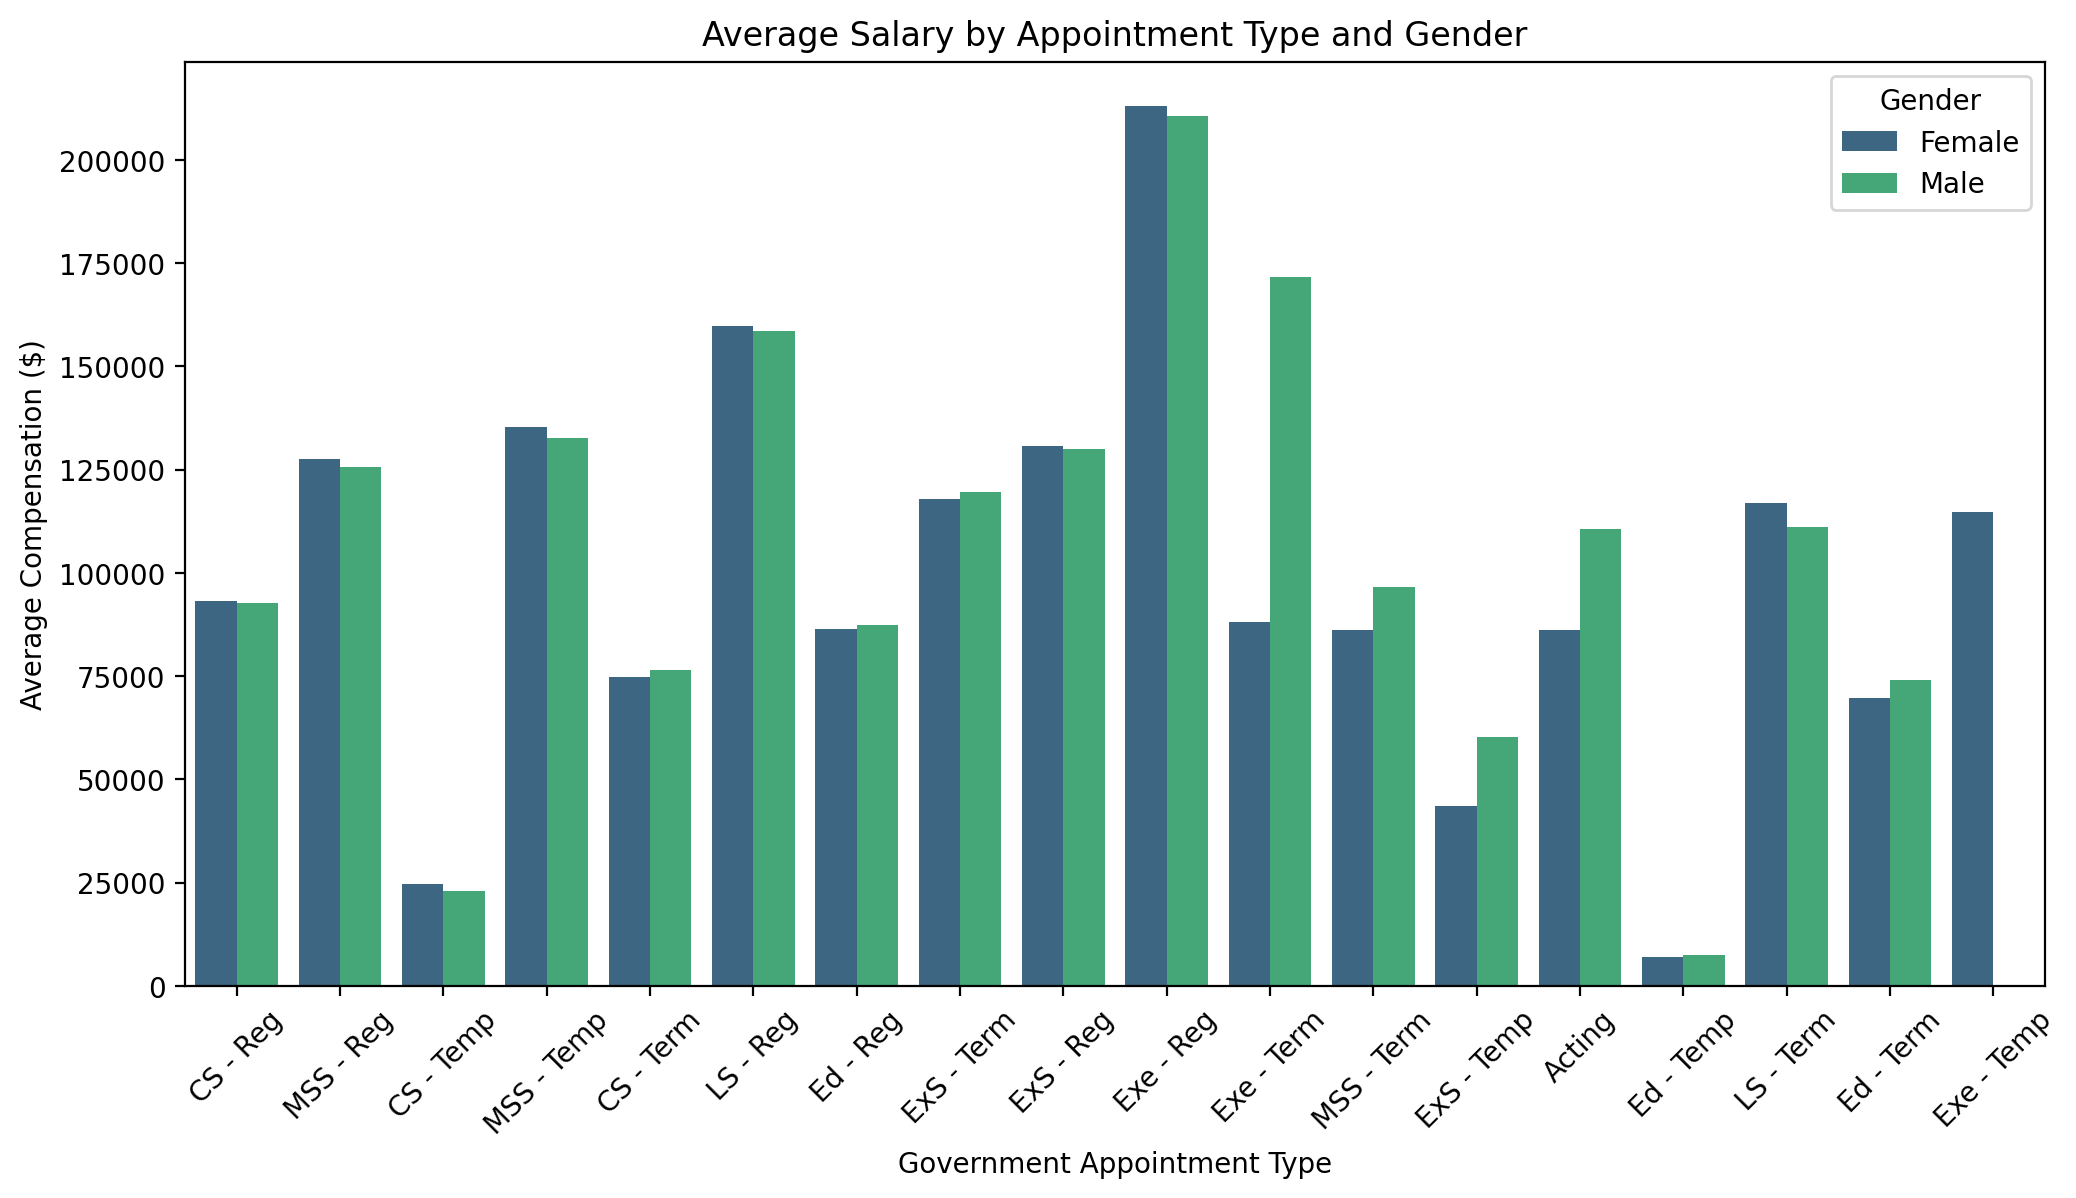

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_new, x='gvt_type_of_appt', y='comprate', hue='gender', palette='viridis', errorbar=None)
plt.title('Average Salary by Appointment Type and Gender')
plt.xlabel('Government Appointment Type')
plt.ylabel('Average Compensation ($)')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.savefig('visualizations/average_salary_by_appt_and_gender.png')
plt.show()

***Interpretation:*** Executive Service (Exe-Reg) appointments have the highest average salaries, coming in above $200,000/year for both genders. On the opposite end of the spectrum, Career Service, Temporary (CS-Temp) and Educational Service, Temporary (Ed-Temp) roles have the lowest salaries. A notable difference is observed in Executive Term (Exe-Term) roles, with males far outpacing females in compensation.

***Statement of Intent:*** This heatmap identifies potential "glass ceilings," or barriers to entry, by calculating the percentage of gender concentration within an organization's top five pay grades. 

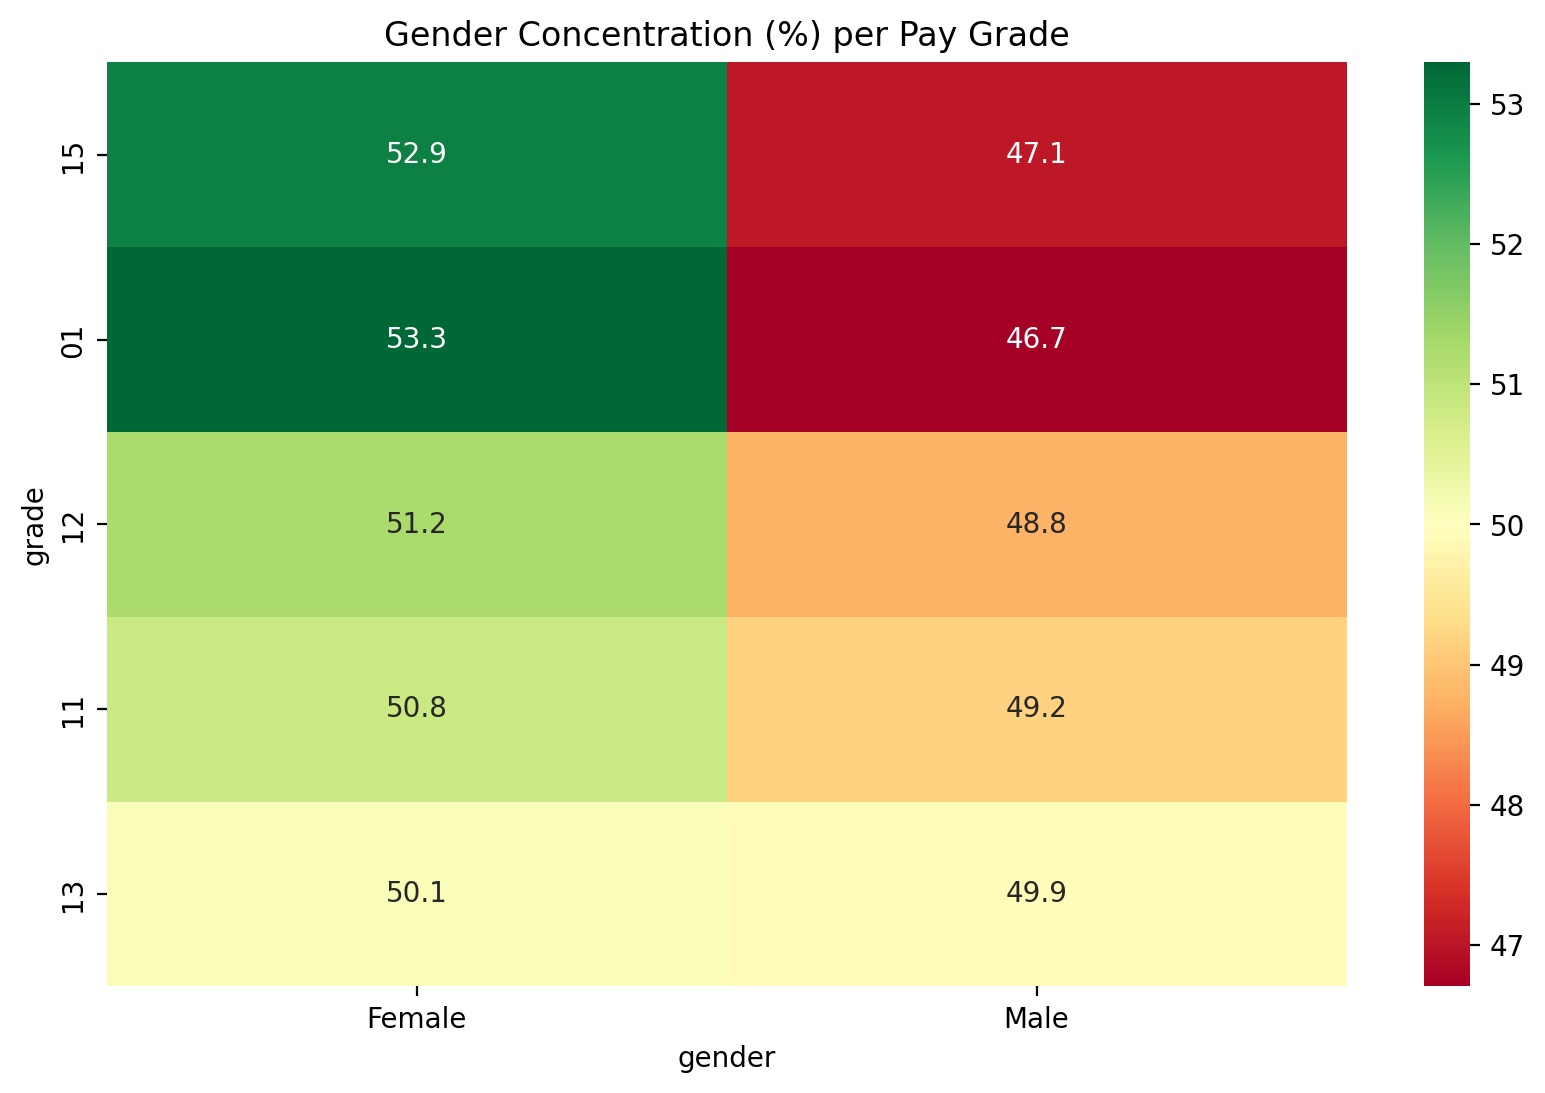

In [26]:
pivot=pd.crosstab(df_new['grade'], df_new['gender'], normalize='index')*100
top_pivot=pivot.loc[top_grades]
plt.figure(figsize=(10,6))
sns.heatmap(top_pivot, annot=True, cmap='RdYlGn', fmt='.1f')
plt.title('Gender Concentration (%) per Pay Grade')
plt.savefig('visualizations/gender_conc.png')
plt.show()

***Interpretation:*** The data shows a relatively balanced gender distribution across the pay grades. Females have a slight majority in Grades 01 and 15, but the distrbution in Grade 13 is nearly an even split. The visualization indicates that for these pay grades, there isn't a significant barrier to entry based on gender.

***Statement of Intent:*** This multivariate scatter plot examines the interaction between an employee's hire date, their salary, and pay grade (represented by bubble size). This visualization illustrates how tenure and promotion impact earnings over time.

In [27]:
#have to create the numeric equivalent of the grade column to perform this analysis
df_new['grade_num']=pd.to_numeric(df_new['grade'], errors='coerce').fillna(0)
df_sample=df_new.sample(1000)
fig4=px.scatter(df_sample,
                x='hiredate',
                y='comprate',
               color='gender', 
                size='grade_num', 
                hover_data=['jobtitle', 'grade'],
               title='Salary Pathway: Hire date, Grade, and Gender',
               color_discrete_map={'Male': 'blue', 'Female':'red'})
fig4.update_layout(
xaxis_title='Date of Hire',
yaxis_title='Annual Compensation ($)',
xaxis_tickangle=-45
)
fig4.show()

***Interpretation:*** The timeline shows a dense cluster of hires betwen 2010 and 2020. Higher pay grades (larger bubbles) are consistently positioned higher on the y-axis (Salary) regardless of hire date. Surprisingly, this suggests that pay grade is a more important factor than tenure/experience. Admittedly, this relationship would be clearer if the data was filtered for one organization or job title, but the trend is still interesting.

***Statement of Intent:***  This box plot allows for simultaneous comparison of the full salary range (min, max, median) for each gender across the different government appointments. I chose this graph because I wanted to see if there were any hidden inequties in the pay scales

In [28]:
fig6=px.box(df_new, x='gvt_type_of_appt', y='comprate', color='gender',
           facet_col='gender', title='Interactive Appointment Type vs. Gender Pay')
fig6.update_xaxes(tickangle=45)
fig6.show()

***Interpretation:*** The interactive hover allows users to identify specific appointments leading to the outliers illustrated above. This provides deeper context into which appointments are highest paid.

***Statement of Intent:*** My "creative choice" was designed with the intention to answer my overarching research question: Which factor has the strongest influence on salary? This bar chart uses correlation coefficients to rank which factor (grade, appointment type, or gender) has the strongest statistical influence on salary.

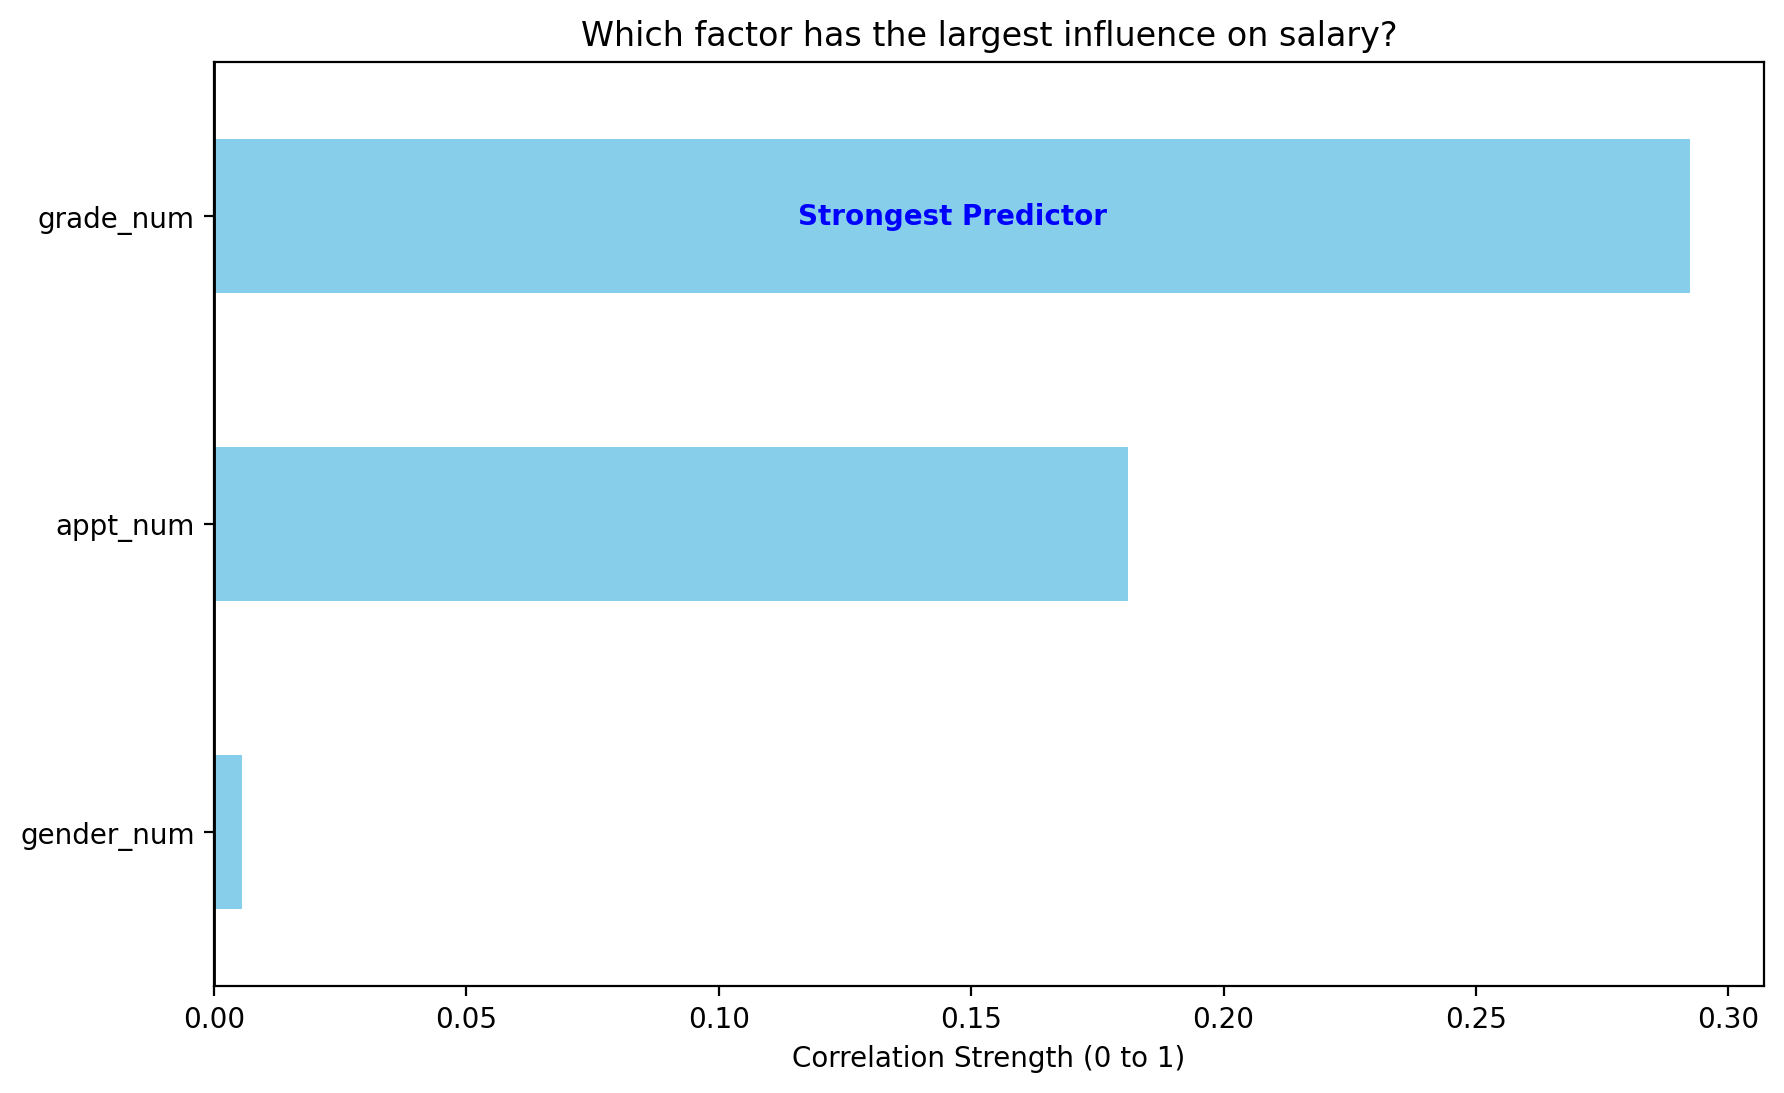

In [29]:
#have to create the numeric versions (category cod) to create the correlation coefficient
df_new['appt_num']=df_new['gvt_type_of_appt'].astype('category').cat.codes
df_new['gender_num']=df_new['gender'].map({'Female':0, 'Male':1})
influence=df_new[['comprate', 'gender_num', 'grade_num', 'appt_num']].corr()['comprate'].drop('comprate')
plt.figure(figsize=(10,6))
influence.sort_values().plot(kind='barh', color='skyblue')
plt.title('Which factor has the largest influence on salary?')
plt.xlabel('Correlation Strength (0 to 1)')
plt.axvline(0, color='black', lw=1)
max_val=influence.max()
max_idx=len(influence)-1
plt.text(max_val/2, max_idx, "Strongest Predictor", 
         color='blue', fontweight='bold', ha='center', va='center')
plt.savefig('visualizations/strongest_predictor.png')
plt.show()

***Interpretation:*** The graph provides a clear answer to my question: pay grade is the strongest predictor of salary (correlation ~0.30). Appointment type is the second most influential factor and gender is the least influential. This confirms that while individual gaps exist, the data doesn't have evidence of gender being a systematic driver of compensation. 

## Additional Analysis

***Statement of Intent:*** This box plot examines the internal pay consistency of the most common job titles in the dataset. I was curious to see which roles had more standardized pay versus roles that had more variance

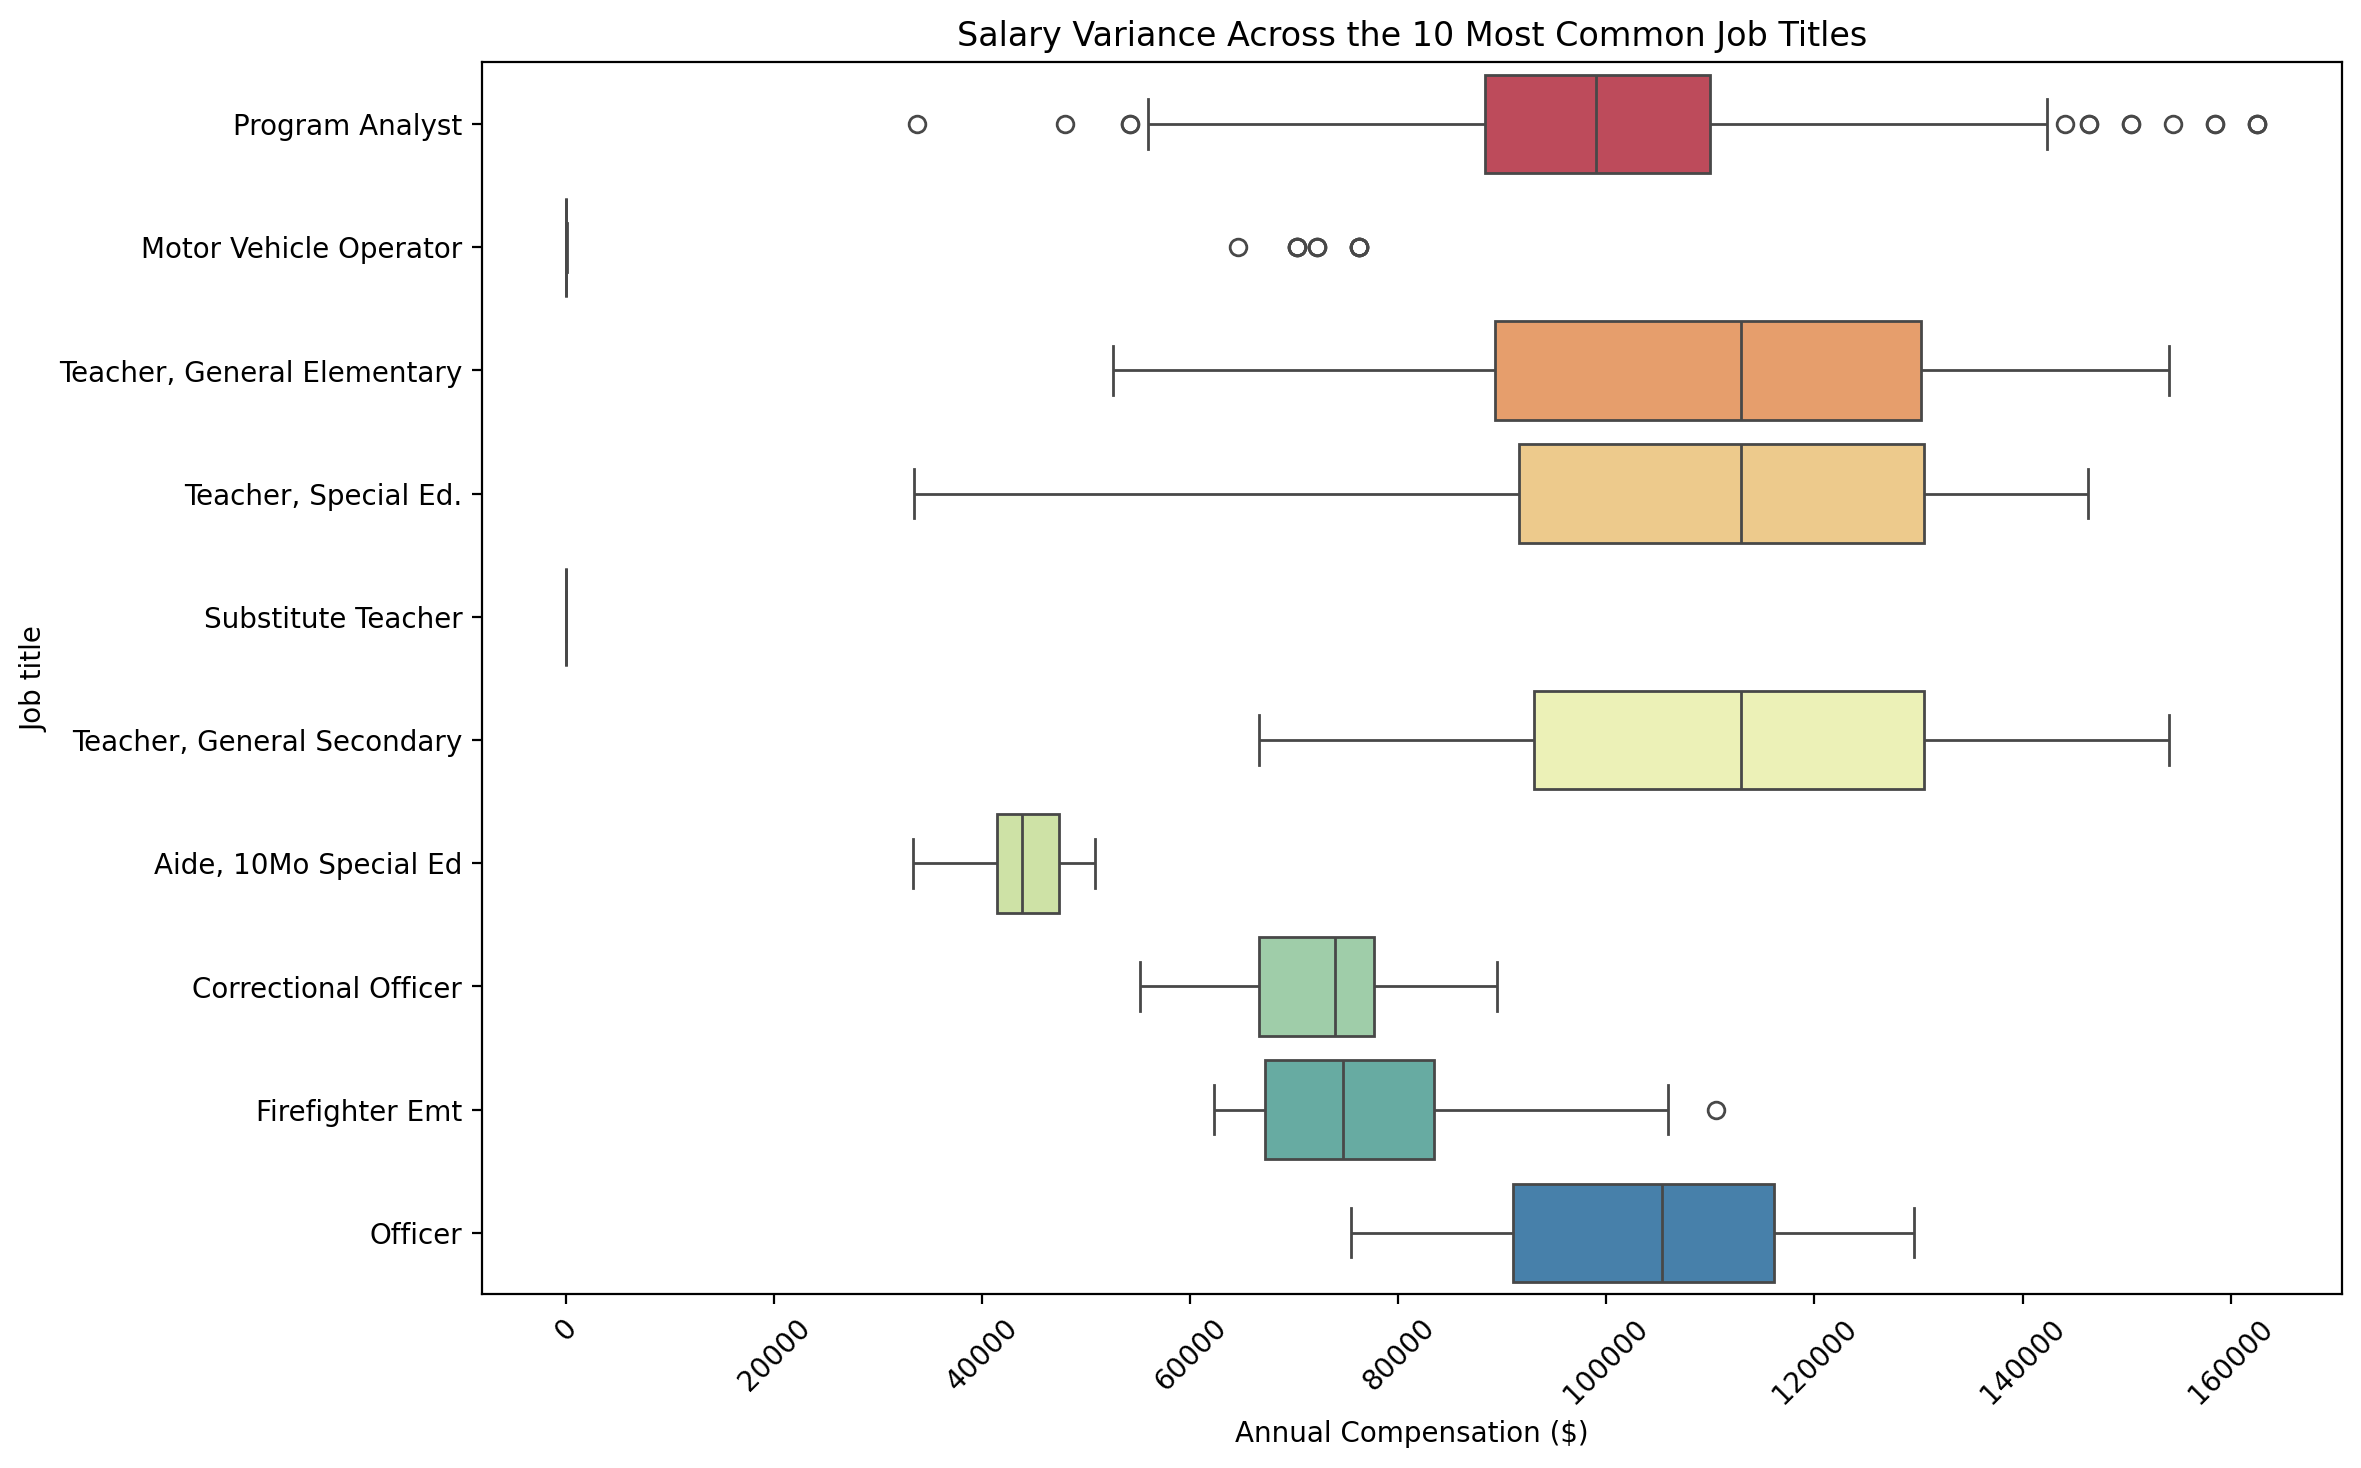

In [30]:
top_jobs=df_new['jobtitle'].value_counts().nlargest(10).index
subset_jobs=df_new[df_new['jobtitle'].isin(top_jobs)]
plt.figure(figsize=(12,8))
sns.boxplot(data=subset_jobs, x='comprate', y='jobtitle', hue='jobtitle', palette='Spectral', legend=False)
plt.title('Salary Variance Across the 10 Most Common Job Titles')
plt.xlabel('Annual Compensation ($)')
plt.ylabel('Job title')
plt.xticks(rotation=45)
plt.savefig('visualizations/common_jobs_salary.png')
plt.show()

***Interpretation:*** While my previous analysis focused on pay grade, this graph illustrates that there's significant salary variance even within the same job title. Some titles have narrow boxes, indicating more standardized pay, while others have long "whiskers," or many outliers.

***Statement of Intent:*** This bar chart identifies which specific agencies within DC have the highest financial committment to employee compensation.

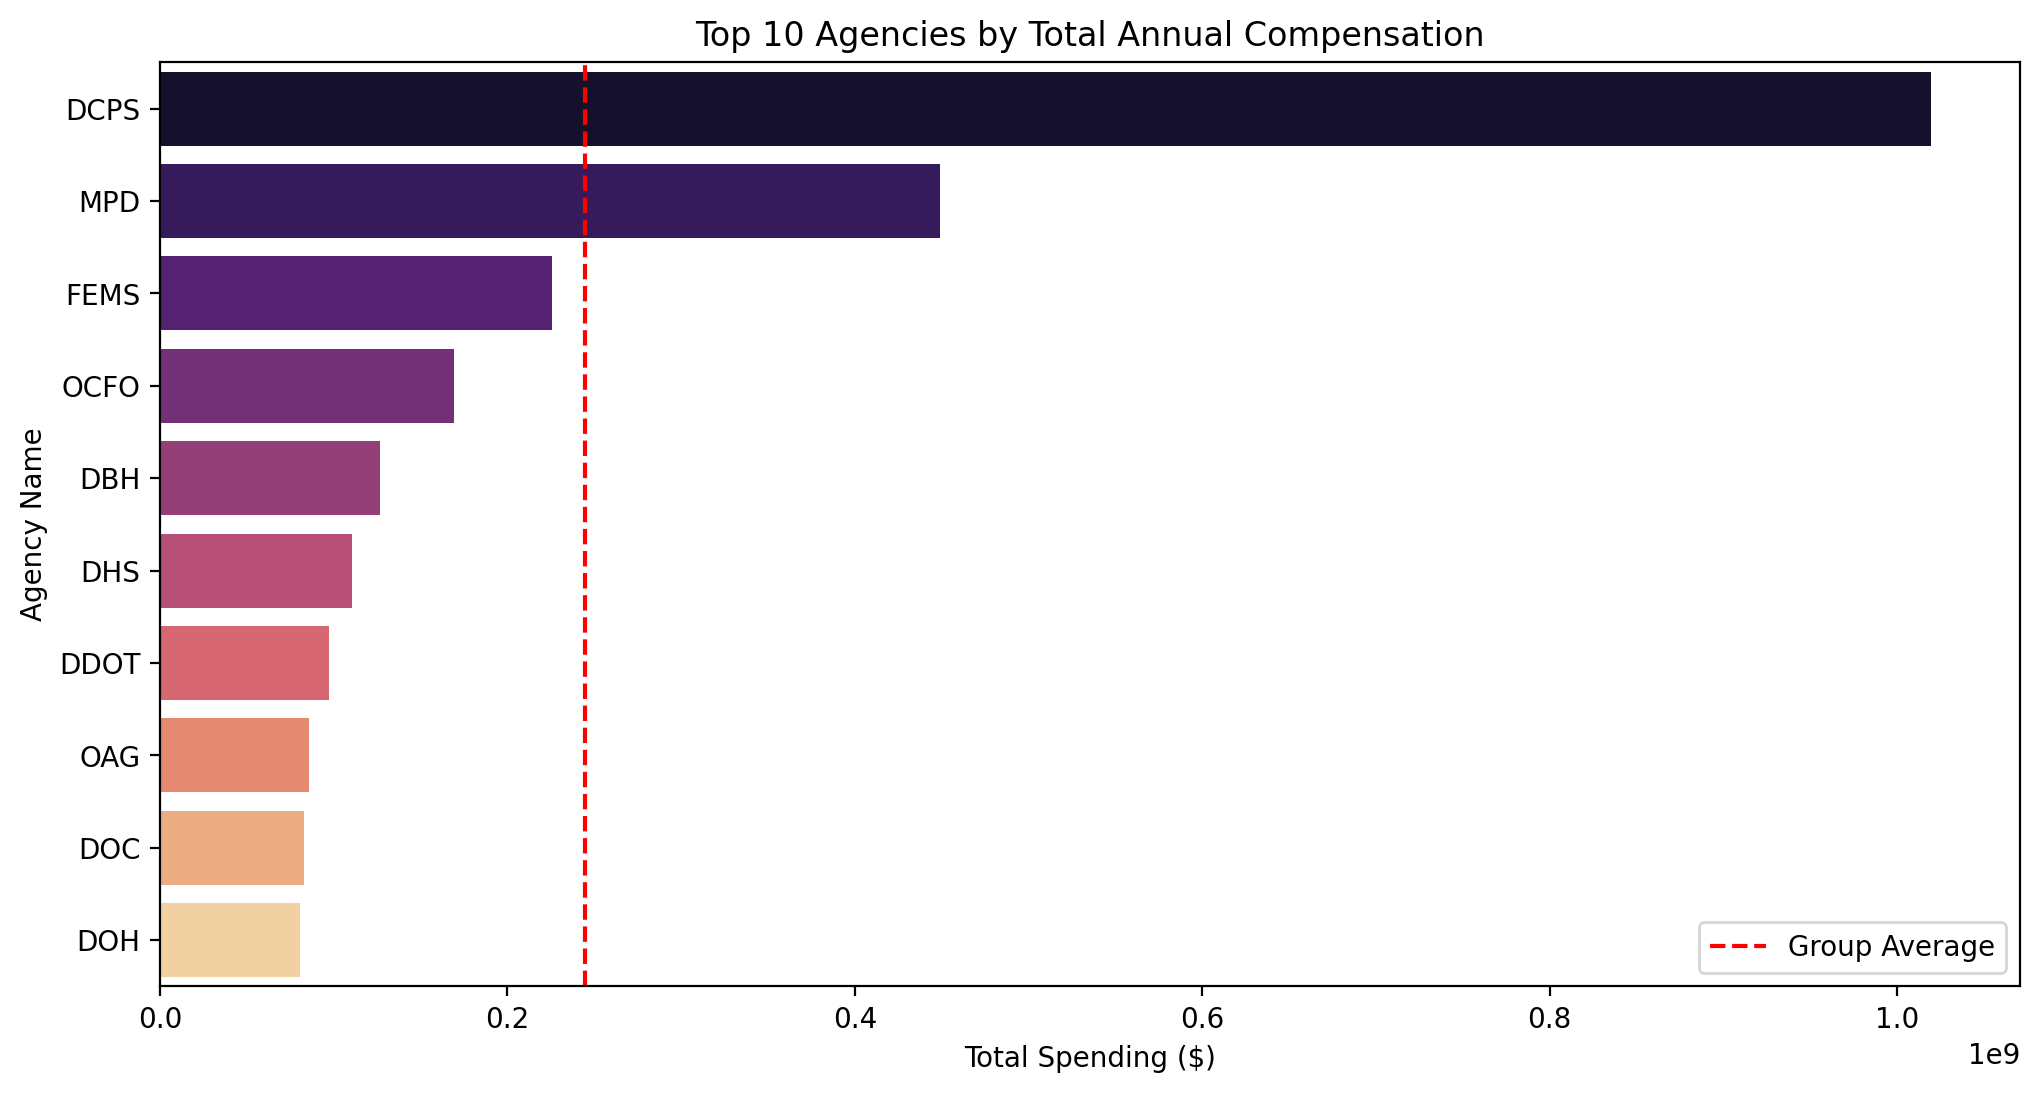

In [31]:
agency_spend=df_new.groupby('descrshort')['comprate'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=agency_spend, x='comprate', y='descrshort', hue='descrshort', palette='magma', legend=False)
plt.title('Top 10 Agencies by Total Annual Compensation')
plt.xlabel('Total Spending ($)')
plt.ylabel('Agency Name')
plt.axvline(agency_spend['comprate'].mean(), color='red', linestyle='--', label='Group Average')
plt.legend()
plt.savefig('visualizations/top_10_agencies.png')
plt.show()

***Interpretation:*** DC Public Schools (DCPS) has the largest financial committment to employee compensation. Admittedly, this result was surprising. I like this graph because it shifts my analysis away from individual demographics to organizational scale. A handful of agencies account for the majority of the payroll budget. This is also great insight into understanding which sectors have the largest workforce footprint

## Insights and Conclusion

Overall, this was a very interesting project. Because gender was a simulated variable, I knew that I wouldn't see significant influence on compensation rate. Even though it wasn't reflective of real-world gender trends, the simulated gender data still demonstrates the capability of my code to detect gaps if they were present. Additionally, the answer to my overall research question as that employee pay grade has the largest influence on compensation rate. I found this to be initially surpring because I thought government appointment type would have more influence, but it makes sense that individuals in higher pay grades make more money. I do feel as if I was somewhat limited in my analysis because I couldn't analyze the actual gender trends, so I would've loved to do this with the correct gender assignment entries. I also could've filtered the dataset by organization/agency or job title to see the trends there, but that would be something for future investigation. Overall this was really cool.a

## Saving the cleaned data frame

In [32]:
df_new.to_csv('fp_cleaned_dataset.csv', index=False)